In [1]:
import pandas as pd
from statsbombpy import sb

all_events = pd.read_csv('data/raw/all_events_combined.csv', low_memory=False)
flair_profile = pd.read_csv('data/processed/flair_player_profiles_all.csv')

flair_positions = [
    'Left Wing', 'Right Wing', 'Center Forward',
    'Center Attacking Midfield', 'Left Center Forward',
    'Right Center Forward', 'Left Attacking Midfield',
    'Right Attacking Midfield', 'Left Midfield', 'Right Midfield'
]

In [2]:
# Ambil info match: tanggal, tim home, tim away
match_info = all_events[['match_id', 'competition', 'team']].drop_duplicates()

# Ambil tanggal dari matches StatsBomb
wc_matches = sb.matches(competition_id=43, season_id=106)[['match_id', 'match_date', 'home_team', 'away_team']]
euro_matches = sb.matches(competition_id=55, season_id=282)[['match_id', 'match_date', 'home_team', 'away_team']]
copa_matches = sb.matches(competition_id=223, season_id=282)[['match_id', 'match_date', 'home_team', 'away_team']]

all_matches = pd.concat([wc_matches, euro_matches, copa_matches], ignore_index=True)

print(all_matches.shape)
print(all_matches.head(3))

d:\toni\nutmeg_prediction\.venv\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


(147, 4)
   match_id  match_date home_team away_team
0   3857276  2022-12-01    Canada   Morocco
1   3857271  2022-11-21   England      Iran
2   3857296  2022-12-01   Croatia   Belgium


In [3]:
# Filter flair dribbles dulu
all_dribbles = all_events[all_events['type'] == 'Dribble'].copy()
all_dribbles['dribble_nutmeg'] = all_dribbles['dribble_nutmeg'].fillna(False)

flair_dribbles = all_dribbles[all_dribbles['position'].isin(flair_positions)].copy()

# Gabungkan dengan match info
flair_dribbles = flair_dribbles.merge(all_matches, on='match_id', how='left')

# Derive opponent: kalau tim pemain = home_team, maka lawan = away_team, dan sebaliknya
flair_dribbles['opponent'] = flair_dribbles.apply(
    lambda x: x['away_team'] if x['team'] == x['home_team'] else x['home_team'],
    axis=1
)

print(flair_dribbles[['player', 'team', 'opponent', 'match_date', 'dribble_nutmeg']].head(10))
print(f"\nMissing opponent: {flair_dribbles['opponent'].isnull().sum()}")

                 player     team opponent  match_date dribble_nutmeg
0        Tajon Buchanan   Canada  Morocco  2022-12-01          False
1        Sofiane Boufal  Morocco   Canada  2022-12-01          False
2            Cyle Larin   Canada  Morocco  2022-12-01          False
3          Hakim Ziyech  Morocco   Canada  2022-12-01          False
4            Cyle Larin   Canada  Morocco  2022-12-01          False
5        Tajon Buchanan   Canada  Morocco  2022-12-01          False
6  David Junior Hoilett   Canada  Morocco  2022-12-01          False
7  David Junior Hoilett   Canada  Morocco  2022-12-01          False
8  David Junior Hoilett   Canada  Morocco  2022-12-01           True
9  David Junior Hoilett   Canada  Morocco  2022-12-01          False

Missing opponent: 0


In [4]:
# Agregasi ke level player-match
player_match = flair_dribbles.groupby(
    ['player_id', 'player', 'team', 'match_id', 'match_date', 'opponent', 'competition']
).agg(
    match_dribbles=('dribble_nutmeg', 'count'),
    match_nutmegs=('dribble_nutmeg', 'sum'),
    match_successful_dribbles=('dribble_outcome', lambda x: (x == 'Complete').sum())
).reset_index()

# Urutkan berdasarkan waktu — SANGAT KRUSIAL
player_match['match_date'] = pd.to_datetime(player_match['match_date'])
player_match = player_match.sort_values(['player_id', 'match_date']).reset_index(drop=True)

print(f"Shape: {player_match.shape}")
print(f"Unique players: {player_match['player_id'].nunique()}")
print(f"Rata-rata match per pemain: {player_match.groupby('player_id').size().mean():.1f}")
print(player_match[player_match['player'] == 'Kylian Mbappé Lottin'].head())

Shape: (1018, 10)
Unique players: 403
Rata-rata match per pemain: 2.5
    player_id                player    team  match_id match_date   opponent  \
28     3009.0  Kylian Mbappé Lottin  France   3857279 2022-11-22  Australia   
29     3009.0  Kylian Mbappé Lottin  France   3857266 2022-11-26    Denmark   
30     3009.0  Kylian Mbappé Lottin  France   3857275 2022-11-30    Tunisia   
31     3009.0  Kylian Mbappé Lottin  France   3869152 2022-12-04     Poland   
32     3009.0  Kylian Mbappé Lottin  France   3869354 2022-12-10    England   

   competition  match_dribbles match_nutmegs  match_successful_dribbles  
28     WC 2022               9             1                          4  
29     WC 2022               7             0                          3  
30     WC 2022               2             1                          2  
31     WC 2022               8             0                          7  
32     WC 2022               6             1                          4  


In [5]:
# Rolling features per pemain (hanya dari masa lalu)
player_match['rolling_nutmegs_last5'] = (
    player_match.groupby('player_id')['match_nutmegs']
    .transform(lambda x: x.rolling(5, min_periods=1).sum().shift(1))
)

player_match['rolling_dribbles_last5'] = (
    player_match.groupby('player_id')['match_dribbles']
    .transform(lambda x: x.rolling(5, min_periods=1).sum().shift(1))
)

player_match['rolling_nutmeg_rate_last5'] = (
    player_match['rolling_nutmegs_last5'] / 
    player_match['rolling_dribbles_last5'].replace(0, 1)
)

# Match number per pemain (proxy pengalaman)
player_match['match_number'] = player_match.groupby('player_id').cumcount() + 1

print(player_match[player_match['player'] == 'Kylian Mbappé Lottin']
      [['player', 'match_date', 'opponent', 'match_nutmegs', 
        'rolling_nutmegs_last5', 'rolling_nutmeg_rate_last5', 'match_number']])

                  player match_date   opponent match_nutmegs  \
28  Kylian Mbappé Lottin 2022-11-22  Australia             1   
29  Kylian Mbappé Lottin 2022-11-26    Denmark             0   
30  Kylian Mbappé Lottin 2022-11-30    Tunisia             1   
31  Kylian Mbappé Lottin 2022-12-04     Poland             0   
32  Kylian Mbappé Lottin 2022-12-10    England             1   
33  Kylian Mbappé Lottin 2022-12-14    Morocco             1   
34  Kylian Mbappé Lottin 2022-12-18  Argentina             1   
35  Kylian Mbappé Lottin 2024-06-17    Austria             0   
36  Kylian Mbappé Lottin 2024-06-25     Poland             0   
37  Kylian Mbappé Lottin 2024-07-01    Belgium             0   
38  Kylian Mbappé Lottin 2024-07-05   Portugal             0   
39  Kylian Mbappé Lottin 2024-07-09      Spain             0   

    rolling_nutmegs_last5  rolling_nutmeg_rate_last5  match_number  
28                    NaN                        NaN             1  
29                    1.0    

In [6]:
# Static features dari flair_profile
static_features = flair_profile[['player_id', 'nutmeg_rate', 'dribble_success_rate']].copy()
static_features = static_features.rename(columns={
    'nutmeg_rate': 'career_nutmeg_rate',
    'dribble_success_rate': 'career_dribble_success_rate'
})

# Defensive strength lawan (dari all_events)
winning_outcomes = ['Won', 'Success In Play', 'Success Out']
duel_per_team = all_events[all_events['type'] == 'Duel'].groupby('team').agg(
    total_duels=('type', 'count'),
    duels_won=('duel_outcome', lambda x: x.isin(winning_outcomes).sum())
).reset_index()
duel_per_team['opponent_duel_win_rate'] = duel_per_team['duels_won'] / duel_per_team['total_duels']
duel_per_team = duel_per_team[['team', 'opponent_duel_win_rate']].rename(columns={'team': 'opponent'})

# Gabungkan semua
player_match = player_match.merge(static_features, on='player_id', how='left')
player_match = player_match.merge(duel_per_team, on='opponent', how='left')

print(player_match.shape)
print(player_match.isnull().sum()[player_match.isnull().sum() > 0])

(1018, 17)
rolling_nutmegs_last5          403
rolling_dribbles_last5         403
rolling_nutmeg_rate_last5      403
career_nutmeg_rate             354
career_dribble_success_rate    354
dtype: int64


In [7]:
# Rolling NaN = match pertama, isi dengan 0
player_match['rolling_nutmegs_last5'] = player_match['rolling_nutmegs_last5'].fillna(0)
player_match['rolling_dribbles_last5'] = player_match['rolling_dribbles_last5'].fillna(0)
player_match['rolling_nutmeg_rate_last5'] = player_match['rolling_nutmeg_rate_last5'].fillna(0)

# Career features NaN = pemain dengan <5 dribbles, drop saja
# karena profil mereka tidak reliable
player_match_clean = player_match.dropna(subset=['career_nutmeg_rate', 'career_dribble_success_rate'])

print(f"Sebelum drop: {len(player_match)}")
print(f"Setelah drop: {len(player_match_clean)}")
print(f"Unique players: {player_match_clean['player_id'].nunique()}")
print(f"Missing values: {player_match_clean.isnull().sum().sum()}")

Sebelum drop: 1018
Setelah drop: 664
Unique players: 153
Missing values: 0


In [8]:
player_match_clean.to_csv('data/processed/player_match_features.csv', index=False)
print("Tersimpan!")
print(f"Rata-rata match per pemain: {664/153:.1f}")
print(f"\nKolom tersedia:")
print(player_match_clean.columns.tolist())

Tersimpan!
Rata-rata match per pemain: 4.3

Kolom tersedia:
['player_id', 'player', 'team', 'match_id', 'match_date', 'opponent', 'competition', 'match_dribbles', 'match_nutmegs', 'match_successful_dribbles', 'rolling_nutmegs_last5', 'rolling_dribbles_last5', 'rolling_nutmeg_rate_last5', 'match_number', 'career_nutmeg_rate', 'career_dribble_success_rate', 'opponent_duel_win_rate']


In [9]:
# Pastikan tidak ada tautology
# y = match_nutmegs
# X tidak boleh mengandung match_nutmegs secara langsung

feature_cols = [
    'rolling_nutmeg_rate_last5',  # rolling dari masa lalu
    'rolling_dribbles_last5',      # exposure masa lalu
    'career_nutmeg_rate',          # profil historis
    'career_dribble_success_rate', # profil historis
    'opponent_duel_win_rate',      # kekuatan lawan
    'match_number'                 # pengalaman pemain
]

target = 'match_nutmegs'

print("=== VERIFIKASI ANTI-TAUTOLOGY ===")
print(f"Target (y): {target}")
print(f"\nFitur (X):")
for f in feature_cols:
    print(f"  - {f}")

print(f"\nApakah target ada di fitur? {target in feature_cols}")
print(f"\nDistribusi target:")
print(player_match_clean[target].value_counts().sort_index())

=== VERIFIKASI ANTI-TAUTOLOGY ===
Target (y): match_nutmegs

Fitur (X):
  - rolling_nutmeg_rate_last5
  - rolling_dribbles_last5
  - career_nutmeg_rate
  - career_dribble_success_rate
  - opponent_duel_win_rate
  - match_number

Apakah target ada di fitur? False

Distribusi target:
match_nutmegs
0    514
1    121
2     27
3      2
Name: count, dtype: int64


In [10]:
# Time-series split: train = 80% pertandingan awal, test = 20% terakhir
player_match_clean = player_match_clean.sort_values('match_date')

split_idx = int(len(player_match_clean) * 0.8)
split_date = player_match_clean.iloc[split_idx]['match_date']

train_df = player_match_clean[player_match_clean['match_date'] < split_date]
test_df = player_match_clean[player_match_clean['match_date'] >= split_date]

print(f"Split date: {split_date.date()}")
print(f"Training: {len(train_df)} rows ({train_df['match_date'].min().date()} - {train_df['match_date'].max().date()})")
print(f"Test: {len(test_df)} rows ({test_df['match_date'].min().date()} - {test_df['match_date'].max().date()})")
print(f"\nTarget distribution train: {train_df[target].value_counts().to_dict()}")
print(f"Target distribution test: {test_df[target].value_counts().to_dict()}")

Split date: 2024-07-01
Training: 522 rows (2022-11-20 - 2024-06-30)
Test: 142 rows (2024-07-01 - 2024-07-15)

Target distribution train: {0: 407, 1: 92, 2: 21, 3: 2}
Target distribution test: {0: 107, 1: 29, 2: 6}


In [11]:
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

X_train = train_df[feature_cols].fillna(0)
y_train = train_df[target]

X_test = test_df[feature_cols].fillna(0)
y_test = test_df[target]

# Poisson Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

poisson = PoissonRegressor(alpha=1.0)
poisson.fit(X_train_scaled, y_train)

y_pred_poisson = poisson.predict(X_test_scaled)

mae_poisson = mean_absolute_error(y_test, y_pred_poisson)
rmse_poisson = np.sqrt(mean_squared_error(y_test, y_pred_poisson))

print("=== POISSON REGRESSION (clean) ===")
print(f"MAE  : {mae_poisson:.4f}")
print(f"RMSE : {rmse_poisson:.4f}")

# Baseline comparison
baseline_pred = y_train.mean()
mae_baseline = mean_absolute_error(y_test, [baseline_pred] * len(y_test))
print(f"\nBaseline MAE : {mae_baseline:.4f}")
print(f"Poisson MAE  : {mae_poisson:.4f}")
print(f"Improvement  : {((mae_baseline - mae_poisson) / mae_baseline * 100):.1f}%")

=== POISSON REGRESSION (clean) ===
MAE  : 0.4104
RMSE : 0.5107

Baseline MAE : 0.4247
Poisson MAE  : 0.4104
Improvement  : 3.4%


In [12]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    verbosity=0
)

xgb.fit(X_train, y_train)

y_pred_xgb_train = xgb.predict(X_train)
y_pred_xgb_test = xgb.predict(X_test)

mae_xgb_train = mean_absolute_error(y_train, y_pred_xgb_train)
mae_xgb_test = mean_absolute_error(y_test, y_pred_xgb_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))

print("=== XGBoost (clean) ===")
print(f"MAE train : {mae_xgb_train:.4f}")
print(f"MAE test  : {mae_xgb_test:.4f}")
print(f"Rasio     : {mae_xgb_test/mae_xgb_train:.1f}x")

print(f"\n=== MODEL COMPARISON ===")
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8}")
print("-" * 43)
print(f"{'Baseline':<25} {mae_baseline:>8.4f}")
print(f"{'Poisson':<25} {mae_poisson:>8.4f} {rmse_poisson:>8.4f}")
print(f"{'XGBoost':<25} {mae_xgb_test:>8.4f} {rmse_xgb:>8.4f}")

=== XGBoost (clean) ===
MAE train : 0.2678
MAE test  : 0.3061
Rasio     : 1.1x

=== MODEL COMPARISON ===
Model                          MAE     RMSE
-------------------------------------------
Baseline                    0.4247
Poisson                     0.4104   0.5107
XGBoost                     0.3061   0.4319


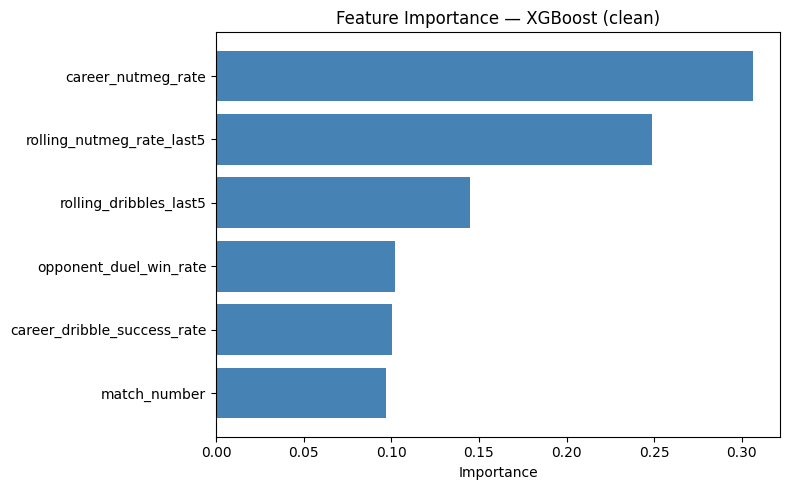

                       feature  importance
2           career_nutmeg_rate    0.306521
0    rolling_nutmeg_rate_last5    0.248720
1       rolling_dribbles_last5    0.145149
4       opponent_duel_win_rate    0.102285
3  career_dribble_success_rate    0.100114
5                 match_number    0.097210


In [13]:
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance — XGBoost (clean)')
plt.tight_layout()
plt.savefig('data/feature_importance_clean.png', dpi=150)
plt.show()

print(feature_importance.sort_values('importance', ascending=False))

In [14]:
# Ambil data terbaru per pemain (form terkini)
latest_per_player = player_match_clean.sort_values('match_date').groupby('player_id').last().reset_index()

X_final = latest_per_player[feature_cols].fillna(0)
latest_per_player['predicted_nutmegs_next_match'] = xgb.predict(X_final)

print("=== TOP 15 PREDICTED — NEXT MATCH ===")
print(latest_per_player[['player', 'team', 'predicted_nutmegs_next_match', 
                          'career_nutmeg_rate', 'rolling_nutmeg_rate_last5']]
      .sort_values('predicted_nutmegs_next_match', ascending=False)
      .head(15).to_string(index=False))

=== TOP 15 PREDICTED — NEXT MATCH ===
                       player        team  predicted_nutmegs_next_match  career_nutmeg_rate  rolling_nutmeg_rate_last5
             Petar Stojanović    Slovenia                      1.323800            0.363636                   0.250000
    Antony Matheus dos Santos      Brazil                      1.211325            0.266667                   0.250000
          João Félix Sequeira    Portugal                      1.156638            0.266667                   0.222222
  Darío Esteban Osorio Osorio       Chile                      1.122631            0.285714                   0.000000
           Barış Alper Yılmaz      Turkey                      0.963270            0.272727                   0.222222
  Lamine Yamal Nasraoui Ebana       Spain                      0.955259            0.222222                   0.181818
                   Harry Kane     England                      0.930102            0.222222                   0.250000
       Vin

In [15]:
import joblib

# Simpan prediksi
latest_per_player.to_csv('data/processed/final_predictions.csv', index=False)

# Simpan model
joblib.dump(xgb, 'data/xgb_model.pkl')
joblib.dump(scaler, 'data/scaler.pkl')

print("Model dan prediksi tersimpan!")
print(f"\n=== FINAL MODEL SUMMARY ===")
print(f"Model: XGBoost (regularized)")
print(f"Training rows: {len(train_df)}")
print(f"Test rows: {len(test_df)}")
print(f"MAE: {mae_xgb_test:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"Improvement vs baseline: {((mae_baseline - mae_xgb_test) / mae_baseline * 100):.1f}%")

Model dan prediksi tersimpan!

=== FINAL MODEL SUMMARY ===
Model: XGBoost (regularized)
Training rows: 522
Test rows: 142
MAE: 0.3061
RMSE: 0.4319
Improvement vs baseline: 27.9%
